## requik example

In [ ]:
import pandas as pd
from utils import get_ranked_lists, get_comprehension_score

corpus = pd.read_csv("../data/requik/inputs/documents.csv")
corpus["edu_val"] = corpus["edu_val"].apply(lambda x: x/5.0)
corpus["reading_comprehension"] = corpus["readability"].apply(lambda x: get_comprehension_score(x, th_high=5, th_low=3))
queries = pd.read_csv("../data/requik/inputs/topics.csv")

sys = get_ranked_lists("results/requik/")
sys_names = {
    "BM25":sys[0], 
    "TF-IDF":sys[1],
    "Dirichlet LM":sys[2], 
    "MonoT5":sys[3], 
    "RankVicuna":sys[4], 
    "RankZephyr":sys[5], 
    # "KORSCE":sys[6], 
    # "REdORank":sys[7]
    }

In [ ]:
corpus.head()

,docno,main_content,readability,edu_val,obj_prob,reading_comprehension
0,RQ_d1,When was the last time the capulin volcano nat...,4.418878,0.4,0.433879,1.000000
1,RQ_d2,Frequently Asked Questions - Capulin Volcano N...,3.050643,0.4,0.792916,1.000000
2,RQ_d3,When was the last time the capulin volcano nat...,4.418878,0.4,0.443689,1.000000
3,RQ_d4,Capulin Volcano National Monument - Britannica...,5.334789,0.6,0.940539,0.982614
4,RQ_d5,Capulin Volcano National Monument - Wikipedia....,4.335093,0.6,0.866994,1.000000


In [ ]:
query = "how many people died in the johnstown flood"
qid = queries.loc[queries["query"]==query]["qid"].values[0]

In [ ]:
retr_docs = []

for key, val in sys_names.items():
    top10_docs = val[val["qid"]==qid][:10]
    top10_docs["ranker"] = key
    retr_docs.append(top10_docs)


retr_doc_nos = pd.concat(retr_docs)
retr_doc_nos["comprehension"] = [corpus.loc[corpus["docno"]==docno]["reading_comprehension"].values[0] for docno in retr_doc_nos["docno"]]
retr_doc_nos["educational value"] = [corpus.loc[corpus["docno"]==docno]["edu_val"].values[0] for docno in retr_doc_nos["docno"]]
retr_doc_nos["objectivity"] = [corpus.loc[corpus["docno"]==docno]["obj_prob"].values[0] for docno in retr_doc_nos["docno"]]
# retr_doc_nos

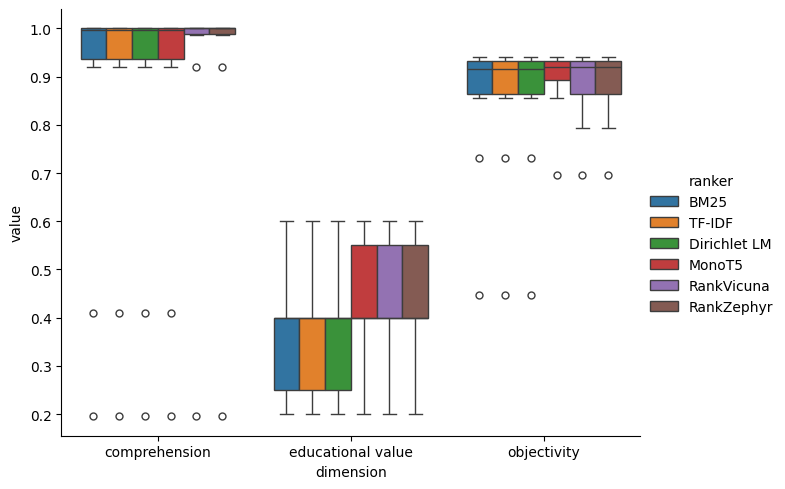

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

df_long = pd.melt(retr_doc_nos[["ranker","comprehension", "educational value", "objectivity"]], "ranker", var_name="user-specific dimension", value_name="")
f = sns.catplot(x="user-specific dimension", hue="ranker", y="", data=df_long, kind="box", height=5, aspect=1.91, legend_out=True)
sns.move_legend(f, "upper center", bbox_to_anchor=(.5, 1.1), ncol=3, title=None)
plt.savefig("figures/requik_example.pdf", dpi=300, bbox_inches="tight")
plt.show()

## kid-friend example

In [9]:
import pandas as pd
from utils import get_ranked_lists, get_comprehension_score

corpus = pd.read_csv("../data/kid-friend-en/en/inputs/documents.csv")
corpus["edu_val"] = corpus["edu_val"].apply(lambda x: x/5.0)
corpus["reading_comprehension"] = corpus["readability"].apply(lambda x: get_comprehension_score(x, th_high=4, th_low=4))
queries = pd.read_csv("../data/kid-friend-en/en/inputs/topics.csv")

sys = get_ranked_lists("results/kid-friend/")
sys_names = {
    "BM25":sys[0], 
    "TF-IDF":sys[1],
    "Dirichlet LM":sys[2], 
    "MonoT5":sys[3], 
    "RankVicuna":sys[4], 
    "RankZephyr":sys[5], 
    # "KORSCE":sys[6], 
    # "REdORank":sys[7]
    }

In [10]:
query = "Bee pollination"
qid = queries.loc[queries["query"]==query]["qid"].values[0]

In [11]:
retr_docs = []

for key, val in sys_names.items():
    top10_docs = val[val["qid"]==qid][:10]
    top10_docs["ranker"] = key
    retr_docs.append(top10_docs)


retr_doc_nos = pd.concat(retr_docs)
retr_doc_nos["comprehension"] = [corpus.loc[corpus["docno"]==docno]["reading_comprehension"].values[0] for docno in retr_doc_nos["docno"]]
retr_doc_nos["educational value"] = [corpus.loc[corpus["docno"]==docno]["edu_val"].values[0] for docno in retr_doc_nos["docno"]]
retr_doc_nos["objectivity"] = [corpus.loc[corpus["docno"]==docno]["obj_prob"].values[0] for docno in retr_doc_nos["docno"]]
# retr_doc_nos

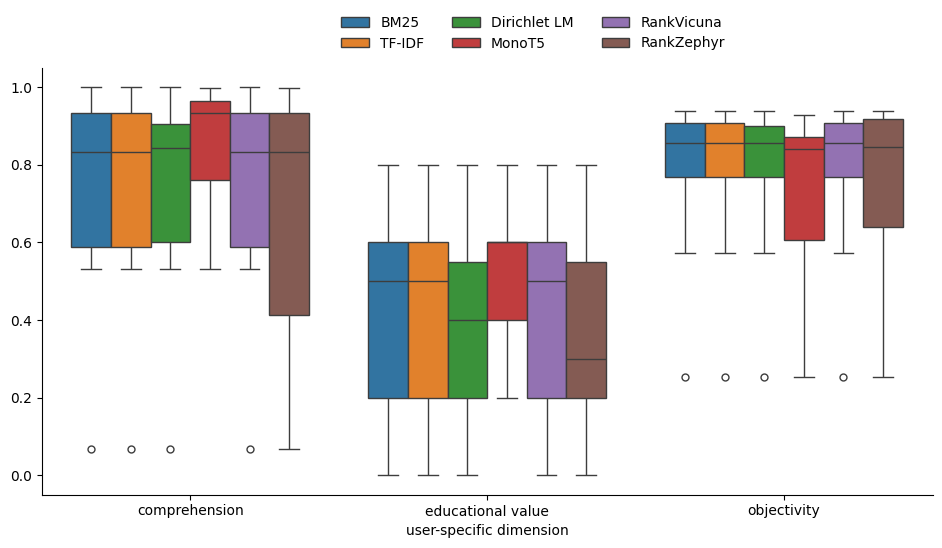

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
# %matplotlib inline

# fig, ax = plt.subplots(figsize=(5, 2))
df_long = pd.melt(retr_doc_nos[["ranker","comprehension", "educational value", "objectivity"]], "ranker", var_name="user-specific dimension", value_name="")
f = sns.catplot(x="user-specific dimension", hue="ranker", y="", data=df_long, kind="box", height=5, aspect=1.91, legend_out=True)
sns.move_legend(f, "upper center", bbox_to_anchor=(.5, 1.1), ncol=3, title=None)
# plt.savefig("figures/kid_friend_example.pdf", dpi=300, bbox_inches="tight")
plt.show()